#Depedencies

In [ ]:
!pip install torch torchvision timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 84.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [ ]:
# mengakses drive
from google.colab import drive
import os

# membuat / modifikasi model deep learning dengan pytorch
import torch
import torch.nn as nn
import torch.optim as optim

# preprocessing data gambar
import torchvision.transforms as transforms
import random

# menampung data gambar berdasarkan class dan membagi per batch selama pelatihan
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# import model pre-trained vit
import timm

# visualisasi dan analisis
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import numpy as np
import pandas as pd
from PIL import Image

# UI untuk proses pelatihan
from tqdm.notebook import tqdm

# Dataset

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = '/content/drive/MyDrive/dataset'
print(os.listdir(base_path))

['train', 'val', 'test']


# Preprocessing

Kelas yang ditemukan: ['healthy', 'leaf curl', 'leaf spot', 'whitefly', 'yellowish']


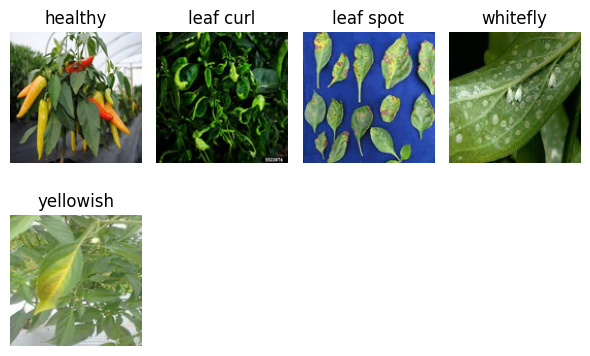

In [ ]:
# Overview Dataset

train_path = os.path.join(base_path, 'train')

# Dapatkan nama kelas dari folder
train_classes = [d for d in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, d))]
train_classes.sort()

print(f"Kelas yang ditemukan: {train_classes}")

# Tampilkan satu sample gambar per kelas
plt.figure(figsize=(6, 4))
resize_dim = (128, 128)

for i, class_name in enumerate(train_classes):
    class_path = os.path.join(train_path, class_name)
    files = [f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))]

    if files:
        img_path = os.path.join(class_path, files[13])
        img = Image.open(img_path).resize(resize_dim)

        plt.subplot(2, 4,i + 1)
        plt.imshow(img)
        plt.title(f"{class_name}")
        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# setting seed agar data preprocessing konsisten tiap experimen
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)

In [ ]:
# transforms untuk dataset train
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandAugment(num_ops=2, magnitude=12),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#transforms untuk dataset val dan test
val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
# mengelola data, label dan melakukan transforms menggunakan ImageFolder

train_dataset = ImageFolder(os.path.join(base_path, 'train'), transform=train_transforms)
val_dataset = ImageFolder(os.path.join(base_path, 'val'), transform=val_test_transforms)
test_dataset = ImageFolder(os.path.join(base_path, 'test'), transform=val_test_transforms)

In [ ]:
# mengatur distribusi data selama pelatihan menggunakan DataLoader

batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Swin

In [ ]:
# mengecek gpu
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [ ]:
def get_swin_model_baseline(num_classes):
    # Load pretrained Swin Transformer
    model = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)

    # Bekukan semua parameter
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze block terakhir di stage terakhir (layer 4)
    last_stage = model.layers[-1]
    last_block = last_stage.blocks[-1]
    for param in last_block.parameters():
        param.requires_grad = True

    # Unfreeze head (classifier)
    for param in model.head.parameters():
        param.requires_grad = True

    # Tidak perlu ganti model.head lagi, karena sudah otomatis
    return model

In [ ]:
#inisialisasi model
num_classes = len(train_dataset.classes)
model_baseline = get_swin_model_baseline(num_classes)
model_baseline = model_baseline.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

In [ ]:
# parameter setting baseline model
learning_rate = 0.0001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_baseline.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, model_path, patience):
    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    best_val_acc = 0.0
    best_val_loss = float('inf')
    best_epoch = 0
    early_stop_counter = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for inputs, labels in train_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

            train_bar.set_postfix({
                'loss': loss.item(),
                'acc': train_correct / train_total
            })

        train_loss = train_loss / len(train_loader.dataset)
        train_acc = train_correct / train_total

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
            for inputs, labels in val_bar:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                val_bar.set_postfix({
                    'loss': loss.item(),
                    'acc': val_correct / val_total
                })

        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_correct / val_total

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        # Simpan model terbaik berdasarkan val_acc
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), model_path)
            print(f"Model terbaik (berdasarkan val acc) disimpan ke {model_path} dengan val akurasi: {val_acc:.4f}")

        # Early stopping berdasarkan val_loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f"EarlyStopping (val_loss): {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print(f"Early stopping triggered karena val_loss tidak membaik selama {patience} epoch. berturut-turut")
            print(f"Model terbaik (berdasarkan val acc): Epoch {best_epoch+1}, Val Acc: {best_val_acc:.4f}")
            break

    print(f"Pelatihan selesai. Epoch terbaik (val acc): Val Acc: {best_val_acc:.4f}")
    return history


In [ ]:
# Latih model
history = train_model(
    model_baseline,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs=100,
    patience=10,
    model_path='swin_model_baseline.pth'
)

Epoch 1/100 [Train]:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 1/100 [Val]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/100 - Train Loss: 1.3876, Train Acc: 0.4525, Val Loss: 1.0122, Val Acc: 0.6400
Model terbaik (berdasarkan val acc) disimpan ke swin_model_baseline.pth dengan val akurasi: 0.6400


Epoch 2/100 [Train]:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 2/100 [Val]:   0%|          | 0/4 [00:00<?, ?it/s]

...

Epoch 14/100 [Val]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 14/100 - Train Loss: 0.1783, Train Acc: 0.9425, Val Loss: 0.7958, Val Acc: 0.7600
EarlyStopping (val_loss): 9/10


Epoch 15/100 [Train]:   0%|          | 0/25 [00:00<?, ?it/s]

Epoch 15/100 [Val]:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 15/100 - Train Loss: 0.1906, Train Acc: 0.9375, Val Loss: 0.7588, Val Acc: 0.7600
EarlyStopping (val_loss): 10/10
Early stopping triggered karena val_loss tidak membaik selama 10 epoch. berturut-turut
Model terbaik (berdasarkan val acc): Epoch 1, Val Acc: 0.8800
Pelatihan selesai. Epoch terbaik (val acc): Val Acc: 0.8800


# Evaluasi

In [ ]:
# Evaluasi model dengan data test
def evaluate_model(model, test_loader):
    model.eval()
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

            # Simpan prediksi dan label untuk confusion matrix
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    # Tampilkan classification report
    class_names = test_dataset.classes
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # Plot confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    # Pastikan fungsi mengembalikan nilai
    return all_preds, all_labels

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]


Classification Report:
              precision    recall  f1-score   support

     healthy       1.00      0.80      0.89        10
   leaf curl       0.71      1.00      0.83        10
   leaf spot       0.90      0.90      0.90        10
    whitefly       0.90      0.90      0.90        10
   yellowish       1.00      0.80      0.89        10

    accuracy                           0.88        50
   macro avg       0.90      0.88      0.88        50
weighted avg       0.90      0.88      0.88        50



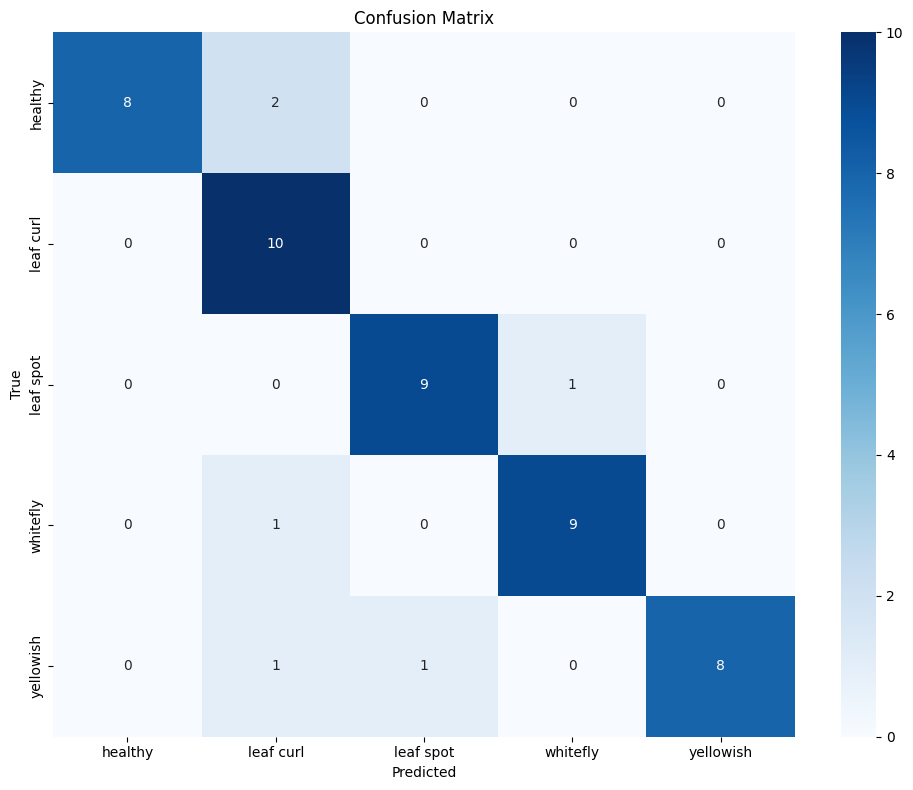

In [ ]:
# Load model terbaik dan evaluasi
model_baseline.load_state_dict(torch.load('swin_model_baseline.pth'))
all_preds, all_labels = evaluate_model(model_baseline, test_loader)

In [ ]:
def evaluate_model_with_probs(model, test_loader):
    model.eval()
    test_correct = 0
    test_total = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating for ROC"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)  # Konversi output ke probabilitas
            _, predicted = torch.max(outputs, 1)

            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

            # Simpan prediksi, label, dan probabilitas
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())  # Simpan probabilitas

    return all_labels, all_probs

In [ ]:
def plot_roc_curve(all_labels, all_probs, class_names):
    # Binarize labels
    all_labels_bin = label_binarize(all_labels, classes=np.arange(len(class_names)))
    all_probs = np.array(all_probs)

    # Perhitungan micro-average ROC curve and ROC area
    fpr_micro, tpr_micro, _ = roc_curve(all_labels_bin.ravel(), all_probs.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)

    # Perhitungan ROC curve and ROC area tiap class
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC curve
    plt.figure(figsize=(6, 5))

    # Plot micro-average ROC curve
    plt.plot(fpr_micro, tpr_micro,
             label=f'(AUC = {roc_auc_micro:.3f})',
             color='blue', linestyle='-', linewidth=3)

    # Plot diagonal
    plt.plot([0, 1], [0, 1], 'k-', lw=2)

    # Plot attributes
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curve', fontsize=12)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, linestyle='-', alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Print AUC scores
    print("\nAUC-ROC Scores per Class:")
    for i, cls in enumerate(class_names):
        print(f"{cls}: {roc_auc[i]:.4f}")
    print(f"Micro-average AUC: {roc_auc_micro:.4f}")


Evaluating for ROC:   0%|          | 0/4 [00:00<?, ?it/s]

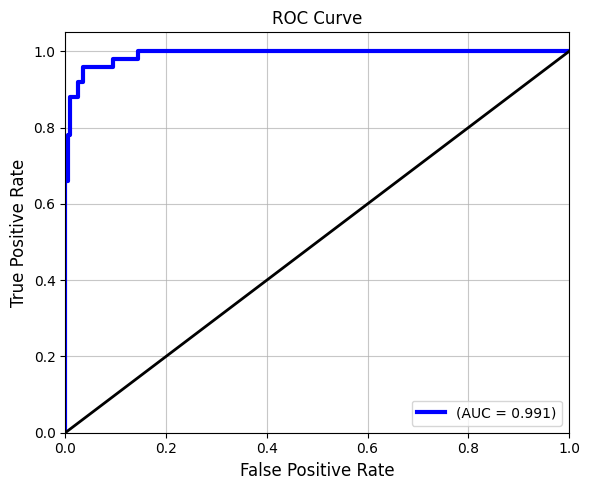


AUC-ROC Scores per Class:
healthy: 0.9950
leaf curl: 0.9825
leaf spot: 0.9975
whitefly: 0.9975
yellowish: 0.9925
Micro-average AUC: 0.9912


In [ ]:
# Evaluasi untuk AOC dan ROC Curve
all_labels, all_probs = evaluate_model_with_probs(model_baseline, test_loader)

# Plot ROC Curve
plot_roc_curve(all_labels, all_probs, test_dataset.classes)